<a href="https://colab.research.google.com/github/Abhishek2114/Deep-learning-and-neural-networks-2/blob/main/DL_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROJECT 2: STRUCTURED DATA PREPROCESSING & ANN



In [12]:
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

data = pd.read_csv("/content/ECommerce_consumer behaviour.csv")

print("Columns:", data.columns)

data = data.dropna()

le = LabelEncoder()
for col in data.select_dtypes(include=['object']).columns:
    data[col] = le.fit_transform(data[col])

target = data.columns[-1]

print("Target column:", target)

X = data.drop(target, axis=1)
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(X_train, y_train, epochs=20, batch_size=16)

loss, acc = model.evaluate(X_test, y_test)
print("ANN Accuracy:", acc)

Columns: Index(['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'product_id', 'add_to_cart_order',
       'reordered', 'department_id', 'department', 'product_name'],
      dtype='object')
Target column: product_name
Epoch 1/20
94758/94758 ━━━━━━━━━━━━━━━━━━━━ 111s 1ms/step - accuracy: 0.0051 - loss: -9839266816.0000
Epoch 2/20
94758/94758 ━━━━━━━━━━━━━━━━━━━━ 140s 1ms/step - accuracy: 0.0051 - loss: -137865691136.0000
Epoch 3/20
94758/94758 ━━━━━━━━━━━━━━━━━━━━ 109s 1ms/step - accuracy: 0.0051 - loss: -591861055488.0000
Epoch 4/20
94758/94758 ━━━━━━━━━━━━━━━━━━━━ 108s 1ms/step - accuracy: 0.0051 - loss: -1593986121728.0000
Epoch 5/20
94758/94758 ━━━━━━━━━━━━━━━━━━━━ 109s 1ms/step - accuracy: 0.0051 - loss: -3365091934208.0000
Epoch 6/20
94758/94758 ━━━━━━━━━━━━━━━━━━━━ 108s 1ms/step - accuracy: 0.0051 - loss: -6122395140096.0000
Epoch 7/20
94758/94758 ━━━━━━━━━━━━━━━━━━━━ 108s 1ms/step - accuracy: 0.0051 - loss: -10086836600832

# PROJECT 3: UNSTRUCTURED DATA PREPROCESSING & CNN

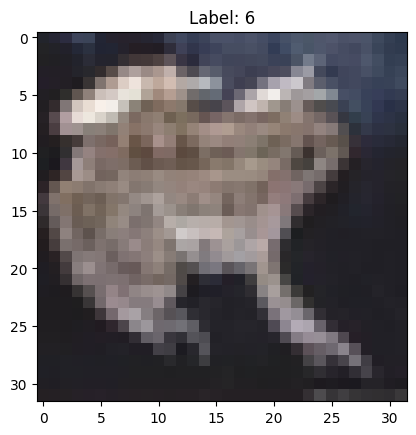

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 44ms/step - accuracy: 0.4431 - loss: 1.5553
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.5796 - loss: 1.1966
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.6345 - loss: 1.0524
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 44ms/step - accuracy: 0.6665 - loss: 0.9516
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.6971 - loss: 0.8731
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.7211 - loss: 0.8091
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.7407 - loss: 0.7497
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 44ms/step - accuracy: 0.7562 - loss: 0.6964
Epoch 9/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.7768 - loss: 0.6372
Epoch 10/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 45ms/step - accuracy: 0.7947 - loss: 0.5877
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6896 - loss: 0.9486
CNN Accuracy: 0.6895999908447266


In [13]:
import pickle
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


def load_batch(file):
    with open(file, 'rb') as f:
        data_dict = pickle.load(f, encoding='bytes')
    return data_dict

X = []
y = []


for i in range(1, 6):
    batch = load_batch(f"/content/data_batch_{i}")
    X.append(batch[b'data'])
    y.append(batch[b'labels'])

X = np.concatenate(X)
y = np.concatenate(y)

X = X.reshape(-1, 3, 32, 32)
X = X.transpose(0, 2, 3, 1)

X = X / 255.0
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

plt.imshow(X_train[0])
plt.title(f"Label: {y_train[0]}")
plt.show()


model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')   # 10 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


model.fit(X_train, y_train, epochs=10, batch_size=64)


loss, acc = model.evaluate(X_test, y_test)
print("CNN Accuracy:", acc)